In [21]:
#Stumble Upon Dataset https://www.kaggle.com/competitions/stumbleupon/data

In [22]:
#loading libraries
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer


In [23]:
#data import
train = pd.read_csv('C:/Users/yezav/OneDrive/Desktop/BABSON/Machine Learning/StumbleUpon/train.tsv', sep='\t', na_values=['?'])
test  = pd.read_csv('C:/Users/yezav/OneDrive/Desktop/BABSON/Machine Learning/StumbleUpon/test.tsv',  sep='\t', na_values=['?'])

print(train.shape, test.shape)   # (7395, 27), (3171, 26)
print(train.dtypes)
train.head()

(7395, 27) (3171, 26)
url                                object
urlid                               int64
boilerplate                        object
alchemy_category                   object
alchemy_category_score            float64
avglinksize                       float64
commonlinkratio_1                 float64
commonlinkratio_2                 float64
commonlinkratio_3                 float64
commonlinkratio_4                 float64
compression_ratio                 float64
embed_ratio                       float64
framebased                          int64
frameTagRatio                     float64
hasDomainLink                       int64
html_ratio                        float64
image_ratio                       float64
is_news                           float64
lengthyLinkDomain                   int64
linkwordscore                       int64
news_front_page                   float64
non_markup_alphanum_characters      int64
numberOfLinks                       int64
numwords_in_

,url,urlid,boilerplate,alchemy_category,alchemy_category_score,avglinksize,commonlinkratio_1,commonlinkratio_2,commonlinkratio_3,commonlinkratio_4,compression_ratio,embed_ratio,framebased,frameTagRatio,hasDomainLink,html_ratio,image_ratio,is_news,lengthyLinkDomain,linkwordscore,news_front_page,non_markup_alphanum_characters,numberOfLinks,numwords_in_url,parametrizedLinkRatio,spelling_errors_ratio,label
0,http://www.bloomberg.com/news/2010-12-23/ibm-p...,4042,"{""title"":""IBM Sees Holographic Calls Air Breat...",business,0.789131,2.055556,0.676471,0.205882,0.047059,0.023529,0.443783,0.0,0,0.090774,0,0.245831,0.003883,1.0,1,24,0.0,5424,170,8,0.152941,0.079130,0
1,http://www.popsci.com/technology/article/2012-...,8471,"{""title"":""The Fully Electronic Futuristic Star...",recreation,0.574147,3.677966,0.508021,0.288770,0.213904,0.144385,0.468649,0.0,0,0.098707,0,0.203490,0.088652,1.0,1,40,0.0,4973,187,9,0.181818,0.125448,1
2,http://www.menshealth.com/health/flu-fighting-...,1164,"{""title"":""Fruits that Fight the Flu fruits tha...",health,0.996526,2.382883,0.562016,0.321705,0.120155,0.042636,0.525448,0.0,0,0.072448,0,0.226402,0.120536,1.0,1,55,0.0,2240,258,11,0.166667,0.057613,1
3,http://www.dumblittleman.com/2007/12/10-foolpr...,6684,"{""title"":""10 Foolproof Tips for Better Sleep ""...",health,0.801248,1.543103,0.400000,0.100000,0.016667,0.000000,0.480725,0.0,0,0.095861,0,0.265656,0.035343,1.0,0,24,0.0,2737,120,5,0.041667,0.100858,1
4,http://bleacherreport.com/articles/1205138-the...,9006,"{""title"":""The 50 Coolest Jerseys You Didn t Kn...",sports,0.719157,2.676471,0.500000,0.222222,0.123457,0.043210,0.446143,0.0,0,0.024908,0,0.228887,0.050473,1.0,1,14,0.0,12032,162,10,0.098765,0.082569,0


In [24]:
#parsing bolerplate json column

def parse_boilerplate(s):
    try:
        d = json.loads(s) if isinstance(s, str) else {}
        return pd.Series({
            'bp_title': (d.get('title') or '').strip(),
            'bp_body':  (d.get('body')  or '').strip(),
            'bp_url':   (d.get('url')   or '').strip(),
        })
    except Exception:
        return pd.Series({'bp_title': '', 'bp_body': '', 'bp_url': ''})

for df in (train, test):
    parsed = df['boilerplate'].apply(parse_boilerplate)
    df[['bp_title', 'bp_body', 'bp_url']] = parsed

# Sanity check
print('Train empty body:', (train['bp_body'] == '').sum())
print('Train empty title:', (train['bp_title'] == '').sum())
print(train[['bp_title', 'bp_body']].head(2))

Train empty body: 689
Train empty title: 433
                                            bp_title                                            bp_body
0  IBM Sees Holographic Calls Air Breathing Batte...  A sign stands outside the International Busine...
1  The Fully Electronic Futuristic Starting Gun T...  And that can be carried on a plane without the...


In [25]:
#checking if both empty titles and bodies in the same row
both_empty = ((train['bp_title'] == '') & (train['bp_body'] == '')).sum()
only_title = ((train['bp_title'] == '') & (train['bp_body'] != '')).sum()
only_body  = ((train['bp_title'] != '') & (train['bp_body'] == '')).sum()

print(f'Both empty: {both_empty}')
print(f'Only title empty: {only_title}')
print(f'Only body empty: {only_body}')

Both empty: 396
Only title empty: 37
Only body empty: 293


In [26]:
#checking if rows with empty title + body can be evergreen
train['both_empty'] = ((train['bp_title'] == '') & (train['bp_body'] == '')).astype(int)
print(train.groupby('both_empty')['label'].agg(['mean','count']))

                mean  count
both_empty                 
0           0.515788   6999
1           0.469697    396


In [27]:
#missing values by column
print(train.isna().sum().sort_values(ascending=False).head(10))

is_news                   2843
alchemy_category_score    2342
alchemy_category          2342
news_front_page           1248
urlid                        0
boilerplate                  0
url                          0
commonlinkratio_2            0
commonlinkratio_3            0
commonlinkratio_4            0
dtype: int64


In [28]:
#looking at alchemy predicted categories counts
cat_stats = (train.groupby('alchemy_category')['label']
                  .agg(['mean', 'count'])
                  .sort_values('mean'))
print(cat_stats)

                        mean  count
alchemy_category                   
weather             0.000000      4
sports              0.205263    380
computer_internet   0.246622    296
unknown             0.333333      6
gaming              0.368421     76
arts_entertainment  0.371945    941
religion            0.416667     72
law_crime           0.419355     31
science_technology  0.456747    289
culture_politics    0.457726    343
health              0.573123    506
recreation          0.684296   1229
business            0.711364    880


In [29]:
#looking at distribution of numeric features
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', None)

numeric = ['avglinksize','commonlinkratio_1','commonlinkratio_2','commonlinkratio_3',
          'commonlinkratio_4','compression_ratio','embed_ratio','frameTagRatio',
          'hasDomainLink','html_ratio','image_ratio','lengthyLinkDomain',
          'linkwordscore','non_markup_alphanum_characters','numberOfLinks',
          'numwords_in_url','parametrizedLinkRatio','spelling_errors_ratio',
          'alchemy_category_score']

print(train[numeric].describe().T[['mean','50%','std','min','max']].round(3))

                                    mean       50%       std    min         max
avglinksize                        2.762     2.088     8.620  0.000     363.000
commonlinkratio_1                  0.468     0.481     0.203  0.000       1.000
commonlinkratio_2                  0.214     0.202     0.147  0.000       1.000
commonlinkratio_3                  0.092     0.069     0.096  0.000       0.980
commonlinkratio_4                  0.049     0.022     0.073  0.000       0.980
compression_ratio                  2.255     0.484     5.704  0.000      21.000
embed_ratio                       -0.104     0.000     0.307 -1.000       0.250
frameTagRatio                      0.056     0.046     0.041  0.000       0.444
hasDomainLink                      0.021     0.000     0.144  0.000       1.000
html_ratio                         0.234     0.231     0.052  0.046       0.717
image_ratio                        0.276     0.083     1.919 -1.000     113.333
lengthyLinkDomain                  0.660

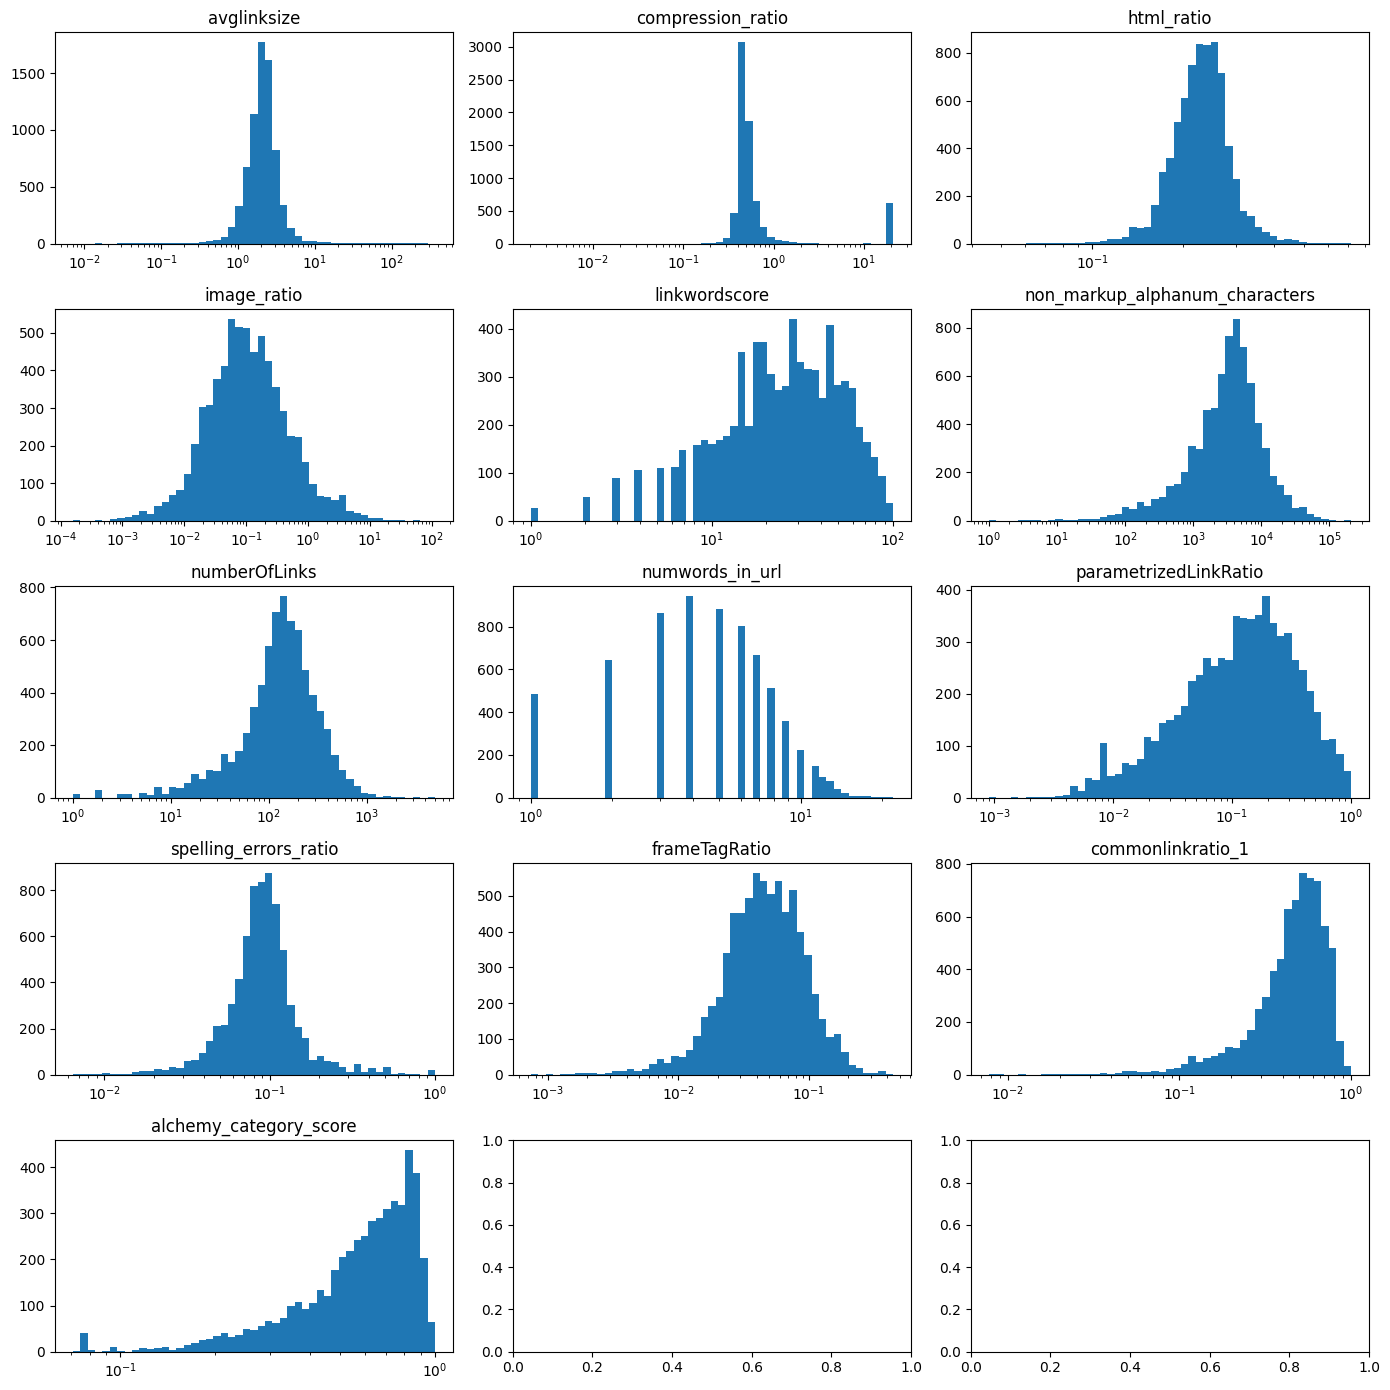

In [30]:
numeric_to_plot = ['avglinksize','compression_ratio','html_ratio','image_ratio',
                  'linkwordscore','non_markup_alphanum_characters','numberOfLinks',
                  'numwords_in_url','parametrizedLinkRatio','spelling_errors_ratio',
                  'frameTagRatio','commonlinkratio_1', 'alchemy_category_score']

fig, axes = plt.subplots(5, 3, figsize=(14, 14))
for ax, col in zip(axes.flat, numeric_to_plot):
    # Clip to 99th percentile so the long tail doesn't squash the plot
   
 #   data = train[col].clip(upper=train[col].quantile(0.99))
 #   ax.hist(data, bins=50)
    data = train[col]
    data = data[data > 0]
    ax.hist(data, bins=np.logspace(np.log10(data.min()), np.log10(data.max()), 50))
    ax.set_xscale('log')
    ax.set_title(col)    
plt.tight_layout()
plt.show()

In [31]:
#which features correlate with label column
numeric = ['avglinksize','commonlinkratio_1','commonlinkratio_2','commonlinkratio_3',
          'commonlinkratio_4','compression_ratio','embed_ratio','frameTagRatio',
          'hasDomainLink','html_ratio','image_ratio','lengthyLinkDomain',
          'linkwordscore','non_markup_alphanum_characters','numberOfLinks',
          'numwords_in_url','parametrizedLinkRatio','spelling_errors_ratio',
          'alchemy_category_score']

corrs = train[numeric + ['label']].corr()['label'].drop('label').sort_values()
print(corrs.round(3))

frameTagRatio                    -0.188
linkwordscore                    -0.174
alchemy_category_score           -0.063
compression_ratio                -0.060
spelling_errors_ratio            -0.059
html_ratio                       -0.051
numwords_in_url                  -0.025
image_ratio                      -0.017
hasDomainLink                    -0.005
avglinksize                       0.006
parametrizedLinkRatio             0.011
lengthyLinkDomain                 0.033
embed_ratio                       0.040
numberOfLinks                     0.080
commonlinkratio_4                 0.080
commonlinkratio_1                 0.083
commonlinkratio_2                 0.083
non_markup_alphanum_characters    0.098
commonlinkratio_3                 0.106
Name: label, dtype: float64


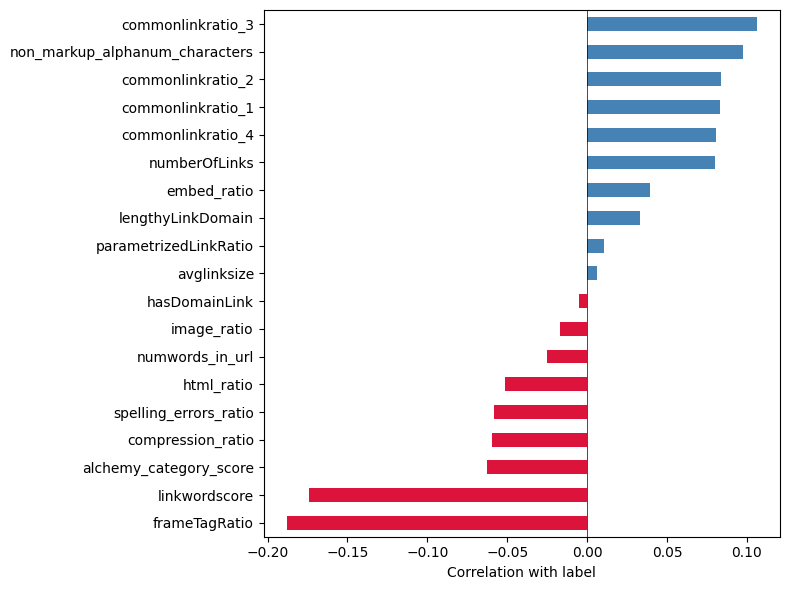

In [32]:
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['crimson' if c < 0 else 'steelblue' for c in corrs]
corrs.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', lw=0.5)
ax.set_xlabel('Correlation with label')
plt.tight_layout()
plt.show()

In [33]:
#target value vs categorical imports
#classification tree + logistic regression + one more (if have time)
#focus on parsing boilerplate coilumn

In [34]:
#% evergreen per alchemy_category
cat_summary = (
    train.groupby('alchemy_category')['label']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'pct_evergreen', 'count': 'n'})
    .sort_values('pct_evergreen', ascending=False)
)
print(cat_summary)

                    pct_evergreen     n
alchemy_category                       
business                 0.711364   880
recreation               0.684296  1229
health                   0.573123   506
culture_politics         0.457726   343
science_technology       0.456747   289
law_crime                0.419355    31
religion                 0.416667    72
arts_entertainment       0.371945   941
gaming                   0.368421    76
unknown                  0.333333     6
computer_internet        0.246622   296
sports                   0.205263   380
weather                  0.000000     4


In [35]:
#% evegreen on the binary/low-cardinality categoricals
for col in ['is_news', 'news_front_page', 'lengthyLinkDomain', 'hasDomainLink', 'framebased']:
    print(f"\n--- {col} ---")
    print(
        train.groupby(col)['label']
        .agg(['mean', 'count'])
        .rename(columns={'mean': 'pct_evergreen', 'count': 'n'})
    )


--- is_news ---
         pct_evergreen     n
is_news                     
1.0           0.516916  4552

--- news_front_page ---
                 pct_evergreen     n
news_front_page                     
0.0                   0.519221  5853
1.0                   0.469388   294

--- lengthyLinkDomain ---
                   pct_evergreen     n
lengthyLinkDomain                     
0                       0.490446  2512
1                       0.525087  4883

--- hasDomainLink ---
               pct_evergreen     n
hasDomainLink                     
0                   0.513678  7238
1                   0.496815   157

--- framebased ---
            pct_evergreen     n
framebased                     
0                 0.51332  7395


In [36]:
#misinng group
for col in ['is_news', 'news_front_page', 'lengthyLinkDomain', 'hasDomainLink', 'framebased']:
    print(f"\n--- {col} ---")
    print(
        train.groupby(col, dropna=False)['label']
        .agg(['mean', 'count'])
        .rename(columns={'mean': 'pct_evergreen', 'count': 'n'})
    )


--- is_news ---
         pct_evergreen     n
is_news                     
1.0           0.516916  4552
NaN           0.507562  2843

--- news_front_page ---
                 pct_evergreen     n
news_front_page                     
0.0                   0.519221  5853
1.0                   0.469388   294
NaN                   0.495994  1248

--- lengthyLinkDomain ---
                   pct_evergreen     n
lengthyLinkDomain                     
0                       0.490446  2512
1                       0.525087  4883

--- hasDomainLink ---
               pct_evergreen     n
hasDomainLink                     
0                   0.513678  7238
1                   0.496815   157

--- framebased ---
            pct_evergreen     n
framebased                     
0                 0.51332  7395


In [37]:
# Drop framebased: constant column (only value 0), zero variance
train = train.drop(columns=['framebased'])
test = test.drop(columns=['framebased'])

# Fill is_news and news_front_page: NaN means "not news" , we fill with 0
# (NaN group's evergreen rate matched the 0 group, so collapsing makes sense)
# Cast to int since fillna leaves dtype as float
for col in ['is_news', 'news_front_page']:
    train[col] = train[col].fillna(0).astype(int)
    test[col] = test[col].fillna(0).astype(int)

# Verify: no NaN, int dtype, only 0/1 values
print("Train:")
for col in ['is_news', 'news_front_page', 'lengthyLinkDomain', 'hasDomainLink']:
    print(f"  {col}: NaN={train[col].isna().sum()}, dtype={train[col].dtype}, values={sorted(train[col].unique())}")

print("\nTest:")
for col in ['is_news', 'news_front_page', 'lengthyLinkDomain', 'hasDomainLink']:
    print(f"  {col}: NaN={test[col].isna().sum()}, dtype={test[col].dtype}, values={sorted(test[col].unique())}")

Train:
  is_news: NaN=0, dtype=int64, values=[np.int64(0), np.int64(1)]
  news_front_page: NaN=0, dtype=int64, values=[np.int64(0), np.int64(1)]
  lengthyLinkDomain: NaN=0, dtype=int64, values=[np.int64(0), np.int64(1)]
  hasDomainLink: NaN=0, dtype=int64, values=[np.int64(0), np.int64(1)]

Test:
  is_news: NaN=0, dtype=int64, values=[np.int64(0), np.int64(1)]
  news_front_page: NaN=0, dtype=int64, values=[np.int64(0), np.int64(1)]
  lengthyLinkDomain: NaN=0, dtype=int64, values=[np.int64(0), np.int64(1)]
  hasDomainLink: NaN=0, dtype=int64, values=[np.int64(0), np.int64(1)]


In [39]:
## Keyword mining from boilerplate
# The alchemy_category analysis showed strong target across topics: 
# business and recreation lean evergreen, sports and computer_internet lean ephemeral. 
# which words in the boilerplate text should matter. 
# Recipe-related vocabulary should be evergreen because cooking instructions stay useful; 
# sports vocabulary should be ephemeral because game results go stale.

#To turn that intuition into features, we need to find the actual words. 
#The approach: within a single category, compare word frequencies between evergreen and ephemeral pages,
#and rank words by how much they skew toward one class.

#Why within a category and not globally? - A global comparison would just rediscover the category-level pattern we already have. 
#The question is: given a page is in 'recreation', which specific words tip it toward evergreen vs ephemeral? 
#Those are the words worth focusing on.

# Method
#1. Filter to one category at a time
#2. Concatenate 'bp_title + 'bp_body' per document
#3. Use 'CountVectorizer' to get raw word counts (frequencies for ratio comparison)
#4. Sum counts separately for evergreen (label=1) and ephemeral (label=0) docs
#5. Normalize by class size (so the larger class doesn't dominate)
#6. Compute log ratio of rates: positive = evergreen-skewed, negative = ephemeral-skewed
#7. Print top 25 from each end

# Parameters:
# min_df=10 for larger categories, min_df=5 for the smaller ones. 
# max_df=0.8 drops words appearing in nearly every document
# stop_words='english' removes function words
# +1 Laplace smoothing on counts to avoid divide-by-zero and dampen rare-word flukes
# Log ratio (instead of raw ratio) makes "twice as common in evergreen" and "twice as common in ephemeral" symmetric around zero

# Categories analyzed (all with n ≥ 296):
#  Evergreen-leaning: recreation, business, health
#  Ephemeral-leaning: arts_entertainment, sports, computer_internet

# Skipped: law_crime, religion, gaming, unknown, weather (too few rows for stable word counts).

# We are looking for: thematic coherence in each list, not specific words. The evergreen list for recreation should look like recipe/hobby vocabulary; 
# the ephemeral list for sports should look like game/event vocabulary.
# Words that pass that eyeball test become candidates for engineered features in the modeling notebook.

def mine_keywords(category, min_df=10, top_n=25):
    mask = train['alchemy_category'] == category
    sub = train[mask].copy()
    sub['text'] = sub['bp_title'].fillna('') + ' ' + sub['bp_body'].fillna('')

    cv = CountVectorizer(min_df=min_df, max_df=0.8, stop_words='english', ngram_range=(1, 1))
    X = cv.fit_transform(sub['text'])
    vocab = np.array(cv.get_feature_names_out())

    y = sub['label'].values
    counts_ever = np.asarray(X[y == 1].sum(axis=0)).ravel()
    counts_ephem = np.asarray(X[y == 0].sum(axis=0)).ravel()
    n_ever, n_ephem = (y == 1).sum(), (y == 0).sum()
    rate_ever = (counts_ever + 1) / n_ever
    rate_ephem = (counts_ephem + 1) / n_ephem
    log_ratio = np.log(rate_ever / rate_ephem)

    print(f"\n{'='*60}\n{category}  (n={len(sub)}, evg={n_ever}, eph={n_ephem})\n{'='*60}")
    print("Top EVERGREEN:")
    for i in np.argsort(log_ratio)[::-1][:top_n]:
        print(f"  {vocab[i]:20s}  lr={log_ratio[i]:+.2f}  evg={counts_ever[i]}  eph={counts_ephem[i]}")
    print("Top EPHEMERAL:")
    for i in np.argsort(log_ratio)[:top_n]:
        print(f"  {vocab[i]:20s}  lr={log_ratio[i]:+.2f}  evg={counts_ever[i]}  eph={counts_ephem[i]}")

# Larger categories
for cat in ['recreation', 'business', 'arts_entertainment', 'health']:
    mine_keywords(cat, min_df=10)

# Smaller categories — relax min_df
for cat in ['sports', 'computer_internet']:
    mine_keywords(cat, min_df=5)


recreation  (n=1229, evg=841, eph=388)
Top EVERGREEN:
  buttermilk            lr=+3.78  evg=94  eph=0
  zucchini              lr=+3.69  evg=86  eph=0
  shrimp                lr=+3.61  evg=79  eph=0
  lasagna               lr=+3.56  evg=75  eph=0
  salmon                lr=+3.53  evg=73  eph=0
  greek                 lr=+3.50  evg=71  eph=0
  ganache               lr=+3.46  evg=68  eph=0
  basil                 lr=+3.45  evg=67  eph=0
  crock                 lr=+3.43  evg=66  eph=0
  drain                 lr=+3.42  evg=65  eph=0
  chunks                lr=+3.40  evg=64  eph=0
  salt1                 lr=+3.39  evg=63  eph=0
  mins                  lr=+3.30  evg=58  eph=0
  stew                  lr=+3.29  evg=57  eph=0
  chewy                 lr=+3.22  evg=53  eph=0
  sushi                 lr=+3.15  evg=100  eph=1
  butterscotch          lr=+3.14  evg=49  eph=0
  meringue              lr=+3.14  evg=49  eph=0
  celery                lr=+3.08  evg=46  eph=0
  springform            lr=+3.06